In [12]:
import os
from os.path import join
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. 데이터 로드
data_dir = './data'
train = pd.read_csv(join(data_dir, 'train.csv'))
test = pd.read_csv(join(data_dir, 'test.csv'))

# 2. 타겟 분리 및 로그 변환
y = train['price']
y = np.log1p(y)
del train['price']

train_len = len(train)
data = pd.concat((train, test), axis=0)

sub_id = test['id']
del data['id']

# 3. 피처 전처리
data['date'] = data['date'].apply(lambda x : str(x[:6])).astype(int)

skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
for c in skew_columns:
    data[c] = np.log1p(data[c])

x = data.iloc[:train_len, :]
sub_x = data.iloc[train_len:, :]

# 4. 기본 모델 정의 및 학습
random_state = 2019
gboost = GradientBoostingRegressor(random_state=random_state)
xgboost = XGBRegressor(random_state=random_state)
lightgbm = LGBMRegressor(random_state=random_state)

models = [gboost, xgboost, lightgbm]
predictions = []

for model in models:
    model.fit(x, y)
    pred = model.predict(sub_x)
    predictions.append(np.expm1(pred))

final_prediction = np.mean(predictions, axis=0)

# 5. 결과 저장
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission['price'] = final_prediction

output_path = './submission.csv'
submission.to_csv(output_path, index=False)
print("Baseline 모델 학습 및 submission.csv 저장 완료.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001607 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
Baseline 모델 학습 및 submission.csv 저장 완료.


In [13]:
import os
from os.path import join
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# 1. 데이터 로드 및 전처리
data_dir = './data'
train = pd.read_csv(join(data_dir, 'train.csv'))
test = pd.read_csv(join(data_dir, 'test.csv'))

y = train['price']
y = np.log1p(y)
del train['price']

train_len = len(train)
data = pd.concat((train, test), axis=0)

sub_id = test['id']
del data['id']

data['date'] = data['date'].apply(lambda x : str(x[:6])).astype(int)

skew_columns = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']
for c in skew_columns:
    data[c] = np.log1p(data[c])

x = data.iloc[:train_len, :]
sub_x = data.iloc[train_len:, :]

# 2. 튜닝된 하이퍼 파라미터 모델 정의
random_state = 2019

model_lgb = LGBMRegressor(
    n_estimators=1500, learning_rate=0.02, max_depth=10, num_leaves=31,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20, random_state=random_state
)

model_xgb = XGBRegressor(
    n_estimators=1500, learning_rate=0.02, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, random_state=random_state
)

model_gbr = GradientBoostingRegressor(
    n_estimators=1000, learning_rate=0.03, max_depth=5, subsample=0.8, random_state=random_state
)

# 3. 모델별 학습 및 예측 진행
print("Starting LightGBM training...")
model_lgb.fit(x, y)
pred_lgb = np.expm1(model_lgb.predict(sub_x))

print("Starting XGBoost training...")
model_xgb.fit(x, y)
pred_xgb = np.expm1(model_xgb.predict(sub_x))

print("Starting GradientBoosting training...")
model_gbr.fit(x, y)
pred_gbr = np.expm1(model_gbr.predict(sub_x))

# 4. 가중 평균 블렌딩 (4:4:2)
final_prediction = (pred_lgb * 0.4) + (pred_xgb * 0.4) + (pred_gbr * 0.2)

# 5. 최종 결과 저장
submission_path = join(data_dir, 'sample_submission.csv')
submission = pd.read_csv(submission_path)
submission['price'] = final_prediction

output_path = './submission.csv'
submission.to_csv(output_path, index=False)
print("Ensemble 모델 학습 완료 및 submission.csv 업데이트 성공.")

Starting LightGBM training...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001631 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2338
[LightGBM] [Info] Number of data points in the train set: 15035, number of used features: 19
[LightGBM] [Info] Start training from score 13.048122
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Starting XGBoost training...
Starting 

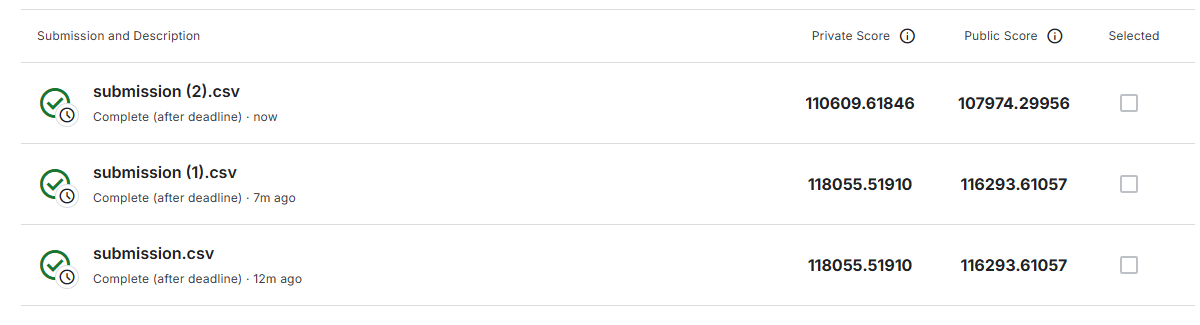